In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib
import colormaps as cmaps
from matplotlib.colors import ListedColormap
import pandas as pd

In [3]:
GPP_tree_MYD_base = xr.open_dataset("/home/druijsch/scripts/2026_05_21_GPP_anom_per_PFT_during_MYDS/GPP_tree_LPJML_baseline_01deg_MYD_mean.nc").GPP
GPP_tree_MYD_base

<xarray.DataArray 'GPP' (lat: 1397, lon: 3600)> Size: 20MB
[5029200 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      PFT-specific GPP

In [4]:
GPP_tree_MYD_DM = xr.open_dataset("/home/druijsch/scripts/2026_05_21_GPP_anom_per_PFT_during_MYDS/GPP_tree_LPJML_droughtmort_01deg_MYD_mean.nc").GPP
GPP_tree_MYD_DM

<xarray.DataArray 'GPP' (lat: 1397, lon: 3600)> Size: 20MB
[5029200 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      PFT-specific GPP

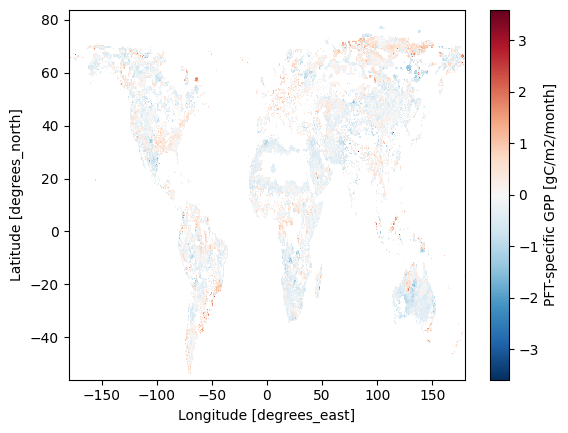

In [5]:
GPP_tree_MYD_base.plot()

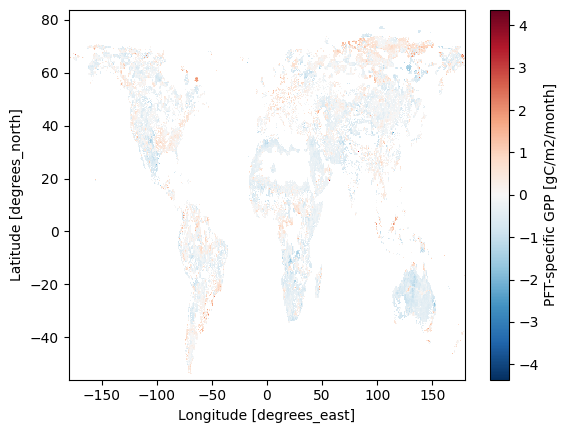

In [6]:
GPP_tree_MYD_DM.plot()

In [7]:
GPP_MYD_PFT_DM = xr.open_dataset("/home/druijsch/scripts/2026_04_28_GPP_anom_MYD_per_PFT/GPP_PFT_stan_DM_MYD_mean_2000_2019.nc").GPP[0:8]
GPP_MYD_PFT_base = xr.open_dataset("/home/druijsch/scripts/2026_04_28_GPP_anom_MYD_per_PFT/GPP_PFT_stan_base_MYD_mean_2000_2019.nc").GPP[0:8]
GPP_MYD_PFT_base

<xarray.DataArray 'GPP' (pft: 8, lat: 1397, lon: 3600)> Size: 161MB
[40233600 values with dtype=float32]
Coordinates:
  * pft      (pft) int32 32B 1 2 3 4 5 6 7 8
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      PFT-specific GPP

In [2]:
base_PFT_FPC = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/fpc.nc").FPC[-1][1:]
base_PFT_FPC['pft'] = base_PFT_FPC['pft'] - 1
base_PFT_FPC

DM_PFT_FPC = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/fpc.nc").FPC[-1][1:]
DM_PFT_FPC['pft'] = DM_PFT_FPC['pft'] - 1
DM_PFT_FPC

<xarray.DataArray 'FPC' (pft: 11, lat: 1397, lon: 3600)> Size: 221MB
[55321200 values with dtype=float32]
Coordinates:
  * pft      (pft) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     object 8B 2019-12-16 00:00:00
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

/scratch-local/77370/ipykernel_4189804/1455253286.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmaps.vegetation_ClarkU, num_colors)


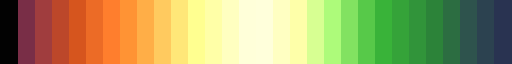

In [8]:
# Number of discrete colors to use
num_colors = 30

# Get the vegetation_ClarkU colormap
cmap = plt.cm.get_cmap(cmaps.vegetation_ClarkU, num_colors)

# Define brightness change parameters
outer_brightness = 0.01
middle_brightness = 0.4

# Calculate brightness changes
brightness_changes = np.linspace(outer_brightness, middle_brightness, num_colors // 2)

# Modify the colors to make yellow and green lighter
colors = cmap(np.linspace(0, 1, num_colors))
colors[:num_colors // 2] += brightness_changes[:, np.newaxis]  # Increase brightness for yellow
colors[num_colors // 2:] += brightness_changes[::-1][:, np.newaxis]  # Increase brightness for green

# Ensure colors stay within the valid RGBA range of 0 to 1
colors = colors.clip(0.0, 1.0)

# Create a ListedColormap object
discrete_cmap = ListedColormap(colors)
discrete_cmap



In [9]:
pft_names = [
    "Tropical broadleaved evergreen tree",
    "Tropical broadleaved raingreen tree",
    "Temperate needleleaved evergreen tree",
    "Temperate broadleaved evergreen tree",
    "Temperate broadleaved summergreen tree",
    "Boreal needleleaved evergreen tree",
    "Boreal broadleaved summergreen tree",
    "Boreal needleleaved summergreen tree"
]

In [10]:
lsm = xr.open_dataset("/projects/prjs2023/chapter3/remapped_masks/land-sea-mask_01deg_shifted.nc").lsm
lsm

<xarray.DataArray 'lsm' (time: 1, lat: 1800, lon: 3600)> Size: 52MB
[6480000 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2023-01-01
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  land_binary_mask
    long_name:      Land-sea mask
    units:          (0 - 1)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import seaborn as sns
import numpy as np

# --------------------------------------------------
# Align mask
# --------------------------------------------------
lsm = lsm.interp_like(GPP_tree_MYD_base)

# --------------------------------------------------
# Apply masks
# --------------------------------------------------
base_land = (
    GPP_tree_MYD_base
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_base.lat > -60)
)

DM_land = (
    GPP_tree_MYD_DM
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_DM.lat > -60)
)



# --------------------------------------------------
# PFT names
# --------------------------------------------------
pft_names = [
    "Trop BE",
    "Trop BR",
    "Temp NE",
    "Temp BE",
    "Temp BS",
    "Bor NE",
    "Bor BS",
    "Bor BS"
]

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    nrows=8,
    ncols=2,
    width_ratios=[2.8, 1.2],
    hspace=0.35,
    wspace=0.15
)

# --------------------------------------------------
# Projection
# --------------------------------------------------
proj = ccrs.PlateCarree(central_longitude=11)

# ==================================================
# LEFT COLUMN: MAPS
# ==================================================

# -----------------------------------
# BASE MAP
# -----------------------------------
ax_map1 = fig.add_subplot(gs[0:4, 0], projection=proj)

vmin = -1.5
vmax = 1.5

im = base_land.plot(
    ax=ax_map1,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map1.coastlines(linewidth=0.7)

ax_map1.set_title("")


ax_map1.set_title(
    "a) Baseline model",
    fontsize=16,
    loc="left",     
    fontweight='bold'
)



ax_map1.spines['geo'].set_visible(False)

# -----------------------------------
# DM MAP
# -----------------------------------
ax_map2 = fig.add_subplot(gs[4:8, 0], projection=proj)

DM_land.plot(
    ax=ax_map2,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map2.coastlines(linewidth=0.7)

ax_map2.set_title("")

ax_map2.set_title(
    "b) DM model",
    fontsize=16,
    loc="left",
    fontweight='bold'
)



ax_map2.spines['geo'].set_visible(False)

ax_map1.set_global()
ax_map2.set_global()

ax_map1.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax_map2.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

# ==================================================
# COLORBAR
# ==================================================
cbar = fig.colorbar(
    im,
    ax=[ax_map1, ax_map2],
    orientation="horizontal",
    fraction=0.04,
    pad=0.04,
    extend="both"
)

cbar.set_label(
    "Standardized GPP anomaly",
    fontsize=12
)

# ==================================================
# RIGHT COLUMN: KDEs
# ==================================================
kde_axes = []

shared_ax = None

for i in range(8):

    # ----------------------------------------------
    # Shared x-axis
    # ----------------------------------------------
    if i == 0:
        ax = fig.add_subplot(gs[i, 1])
        shared_ax = ax
    else:
        ax = fig.add_subplot(gs[i, 1], sharex=shared_ax)

    # ----------------------------------------------
    # Extract values
    # ----------------------------------------------
    base_vals = (
        GPP_MYD_PFT_base.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_base.lat > -60)
        .values
        .flatten()
    )

    dm_vals = (
        GPP_MYD_PFT_DM.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_DM.lat > -60)
        .values
        .flatten()
    )

    # ----------------------------------------------
    # Remove NaNs
    # ----------------------------------------------
    base_vals = base_vals[np.isfinite(base_vals)]
    dm_vals   = dm_vals[np.isfinite(dm_vals)]

    # ----------------------------------------------
    # Optional subsampling
    # ----------------------------------------------
    max_points = 200000

    if len(base_vals) > max_points:
        base_vals = np.random.choice(
            base_vals,
            max_points,
            replace=False
        )

    if len(dm_vals) > max_points:
        dm_vals = np.random.choice(
            dm_vals,
            max_points,
            replace=False
        )

    # ----------------------------------------------
    # KDE plots
    # ----------------------------------------------
    sns.kdeplot(
        base_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="Baseline", color = 'tab:blue'
    )

    sns.kdeplot(
        dm_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="DM", color = 'tab:purple'
    )

    # ----------------------------------------------
    # Formatting
    # ----------------------------------------------
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 1.5)

    ax.set_title(
        pft_names[i],
        fontsize=11,
        loc="left"
    )

    ax.set_ylabel("")


    # ----------------------------------------------
    # Cleaner shared-axis styling
    # ----------------------------------------------
    if i < 7:
        # remove x-axis labels/ticks for upper panels
        ax.set_xlabel("")
        ax.tick_params(
            axis='x',
            which='both',
            bottom=False,
            labelbottom=False
        )
        
        ax.tick_params(
        axis='y',
        labelleft=False
        )

        # optional: hide bottom spine too
        ax.spines['bottom'].set_visible(False)

    else:
        # keep only on bottom panel
        ax.set_xlabel("Standardized GPP anomaly", fontsize=11)

        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True
        )

    # cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    kde_axes.append(ax)

# ==================================================
# LEGEND
# ==================================================
handles, labels = kde_axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9, 0.9),
    frameon=False,
    fontsize=11
)

# ==================================================
# FINAL LAYOUT
# ==================================================
# plt.tight_layout()

plt.savefig("/home/druijsch/scripts/2026_06_03_drought_response_DM_vs_base_vs_obs/GPP_anom_maps_kdes_v4.png", dpi=300)

plt.show()

In [11]:
colors = {
    "Baseline": "#00FFFF",
    "Drought mort": "#FF00FF",
}

In [13]:
colors.get("Drought mort")

'#FF00FF'

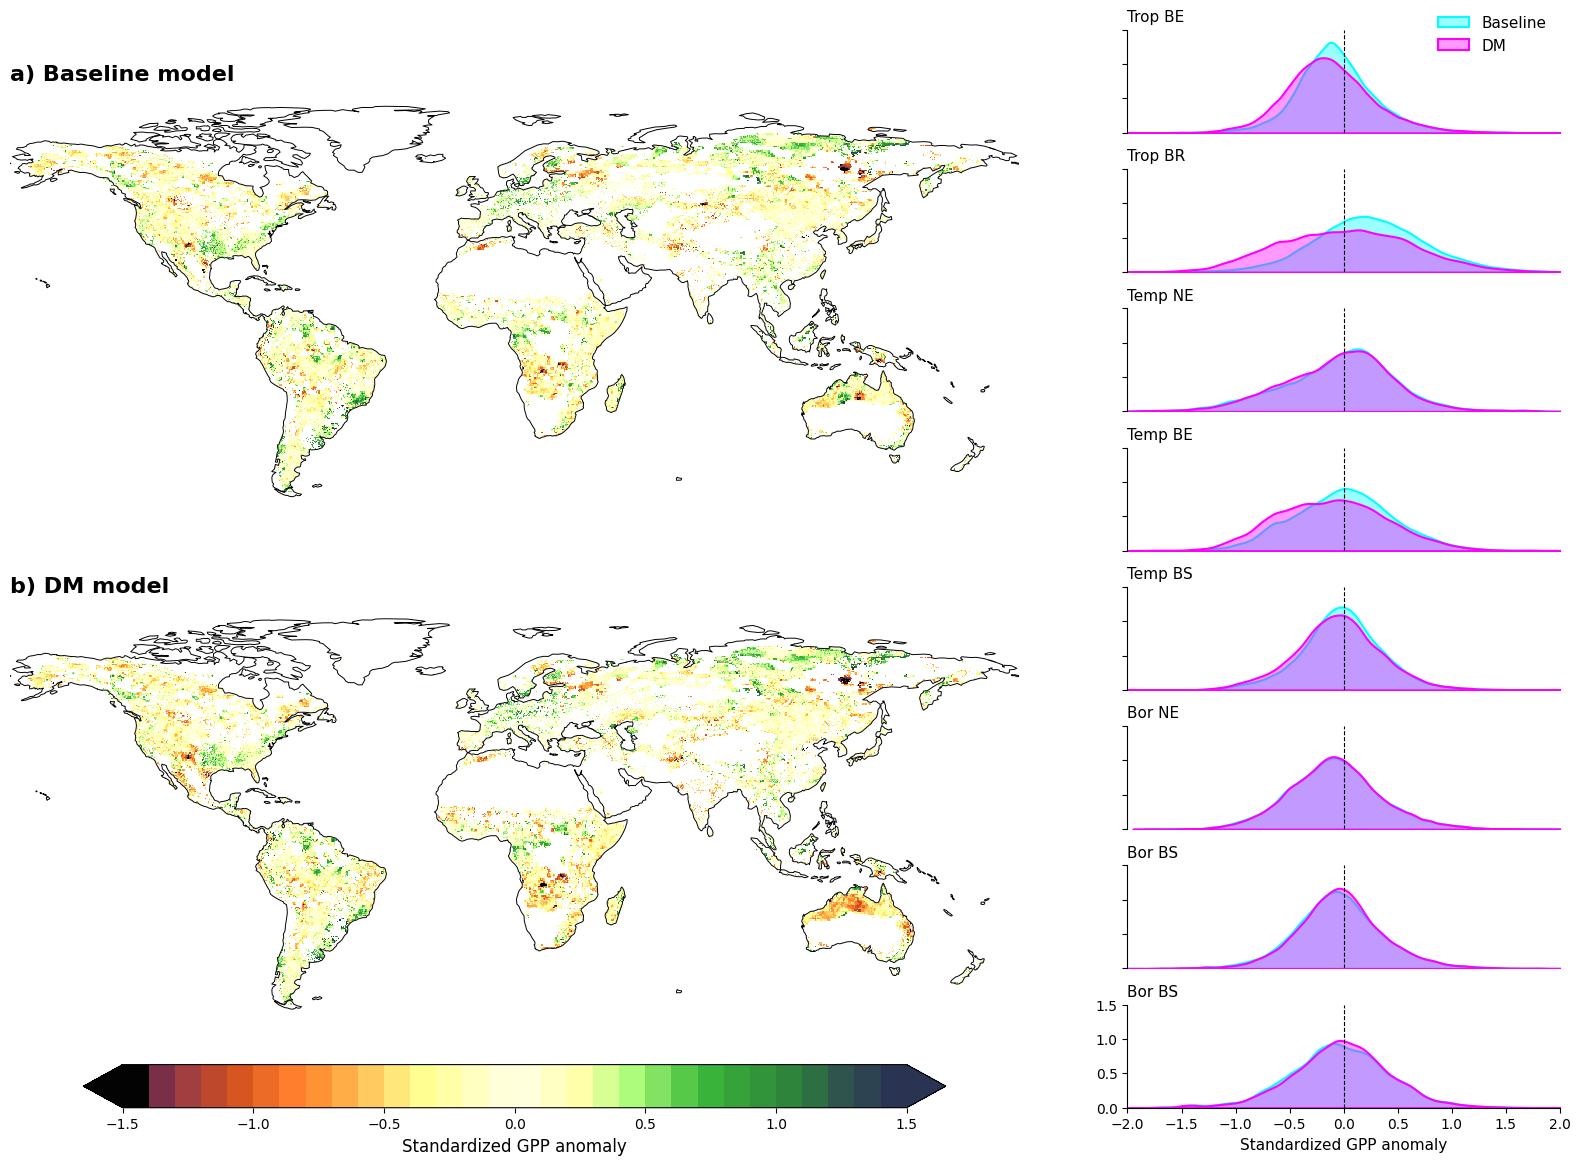

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import seaborn as sns
import numpy as np

# --------------------------------------------------
# Align mask
# --------------------------------------------------
lsm = lsm.interp_like(GPP_tree_MYD_base)

# --------------------------------------------------
# Apply masks
# --------------------------------------------------
base_land = (
    GPP_tree_MYD_base
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_base.lat > -60)
)

DM_land = (
    GPP_tree_MYD_DM
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_DM.lat > -60)
)



# --------------------------------------------------
# PFT names
# --------------------------------------------------
pft_names = [
    "Trop BE",
    "Trop BR",
    "Temp NE",
    "Temp BE",
    "Temp BS",
    "Bor NE",
    "Bor BS",
    "Bor BS"
]

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    nrows=8,
    ncols=2,
    width_ratios=[2.8, 1.2],
    hspace=0.35,
    wspace=0.15
)

# --------------------------------------------------
# Projection
# --------------------------------------------------
proj = ccrs.PlateCarree(central_longitude=11)

# ==================================================
# LEFT COLUMN: MAPS
# ==================================================

# -----------------------------------
# BASE MAP
# -----------------------------------
ax_map1 = fig.add_subplot(gs[0:4, 0], projection=proj)

vmin = -1.5
vmax = 1.5

im = base_land.plot(
    ax=ax_map1,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map1.coastlines(linewidth=0.7)

ax_map1.set_title("")


ax_map1.set_title(
    "a) Baseline model",
    fontsize=16,
    loc="left",     
    fontweight='bold'
)



ax_map1.spines['geo'].set_visible(False)

# -----------------------------------
# DM MAP
# -----------------------------------
ax_map2 = fig.add_subplot(gs[4:8, 0], projection=proj)

DM_land.plot(
    ax=ax_map2,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map2.coastlines(linewidth=0.7)

ax_map2.set_title("")

ax_map2.set_title(
    "b) DM model",
    fontsize=16,
    loc="left",
    fontweight='bold'
)



ax_map2.spines['geo'].set_visible(False)

ax_map1.set_global()
ax_map2.set_global()

ax_map1.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax_map2.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

# ==================================================
# COLORBAR
# ==================================================
cbar = fig.colorbar(
    im,
    ax=[ax_map1, ax_map2],
    orientation="horizontal",
    fraction=0.04,
    pad=0.04,
    extend="both"
)

cbar.set_label(
    "Standardized GPP anomaly",
    fontsize=12
)

# ==================================================
# RIGHT COLUMN: KDEs
# ==================================================
kde_axes = []

shared_ax = None

for i in range(8):

    # ----------------------------------------------
    # Shared x-axis
    # ----------------------------------------------
    if i == 0:
        ax = fig.add_subplot(gs[i, 1])
        shared_ax = ax
    else:
        ax = fig.add_subplot(gs[i, 1], sharex=shared_ax)

    # ----------------------------------------------
    # Extract values
    # ----------------------------------------------
    base_vals = (
        GPP_MYD_PFT_base.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_base.lat > -60)
        .values
        .flatten()
    )

    dm_vals = (
        GPP_MYD_PFT_DM.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_DM.lat > -60)
        .values
        .flatten()
    )

    # ----------------------------------------------
    # Remove NaNs
    # ----------------------------------------------
    base_vals = base_vals[np.isfinite(base_vals)]
    dm_vals   = dm_vals[np.isfinite(dm_vals)]

    # ----------------------------------------------
    # Optional subsampling
    # ----------------------------------------------
    max_points = 200000

    if len(base_vals) > max_points:
        base_vals = np.random.choice(
            base_vals,
            max_points,
            replace=False
        )

    if len(dm_vals) > max_points:
        dm_vals = np.random.choice(
            dm_vals,
            max_points,
            replace=False
        )

    # ----------------------------------------------
    # KDE plots
    # ----------------------------------------------
    sns.kdeplot(
        base_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="Baseline", color = colors.get("Baseline"),
    )

    sns.kdeplot(
        dm_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="DM", color = colors.get("Drought mort"),
    )

    # ----------------------------------------------
    # Formatting
    # ----------------------------------------------
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 1.5)

    ax.set_title(
        pft_names[i],
        fontsize=11,
        loc="left"
    )

    ax.set_ylabel("")


    # ----------------------------------------------
    # Cleaner shared-axis styling
    # ----------------------------------------------
    if i < 7:
        # remove x-axis labels/ticks for upper panels
        ax.set_xlabel("")
        ax.tick_params(
            axis='x',
            which='both',
            bottom=False,
            labelbottom=False
        )
        
        ax.tick_params(
        axis='y',
        labelleft=False
        )

        # optional: hide bottom spine too
        ax.spines['bottom'].set_visible(False)

    else:
        # keep only on bottom panel
        ax.set_xlabel("Standardized GPP anomaly", fontsize=11)

        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True
        )

    # cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    kde_axes.append(ax)

# ==================================================
# LEGEND
# ==================================================
handles, labels = kde_axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9, 0.9),
    frameon=False,
    fontsize=11
)

# ==================================================
# FINAL LAYOUT
# ==================================================
# plt.tight_layout()

plt.savefig("/home/druijsch/scripts/2026_06_03_drought_response_DM_vs_base_vs_obs/GPP_anom_maps_kdes_v4.png", dpi=300)

plt.show()

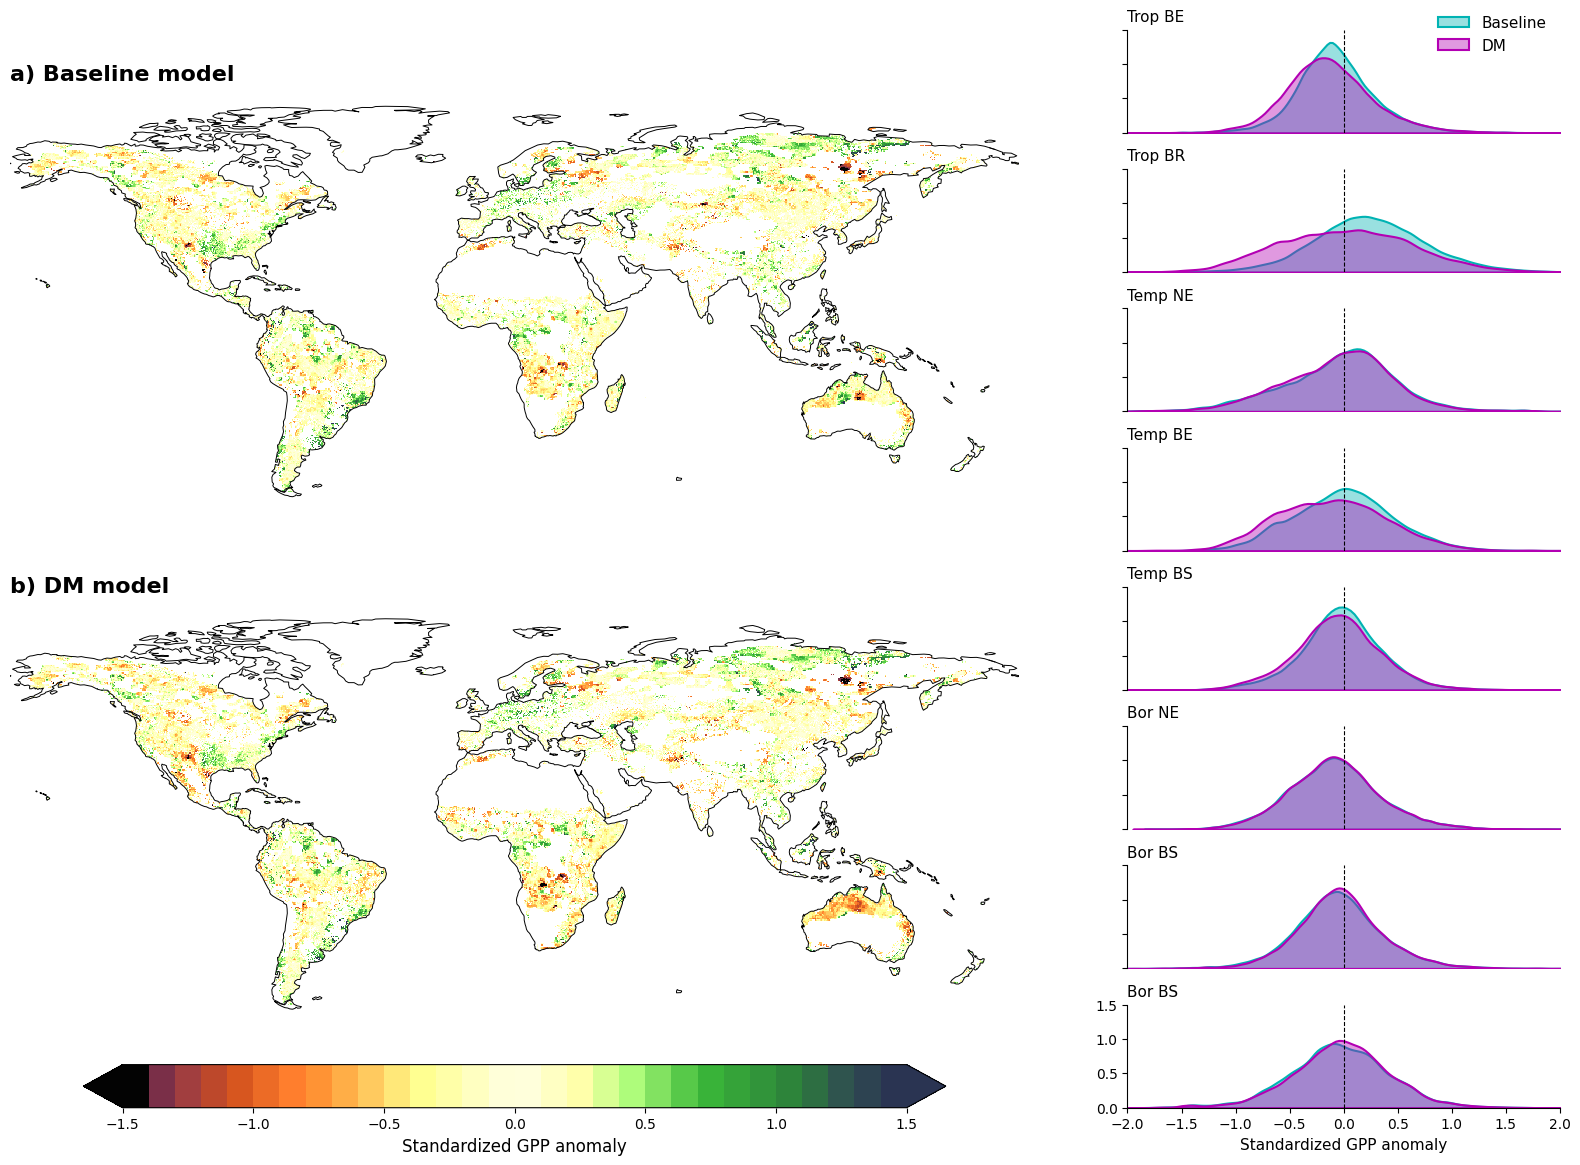

In [15]:
colors = {
    "Baseline": "#00B3B3",
    "Drought mort": "#B300B3",
}

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import seaborn as sns
import numpy as np

# --------------------------------------------------
# Align mask
# --------------------------------------------------
lsm = lsm.interp_like(GPP_tree_MYD_base)

# --------------------------------------------------
# Apply masks
# --------------------------------------------------
base_land = (
    GPP_tree_MYD_base
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_base.lat > -60)
)

DM_land = (
    GPP_tree_MYD_DM
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_DM.lat > -60)
)



# --------------------------------------------------
# PFT names
# --------------------------------------------------
pft_names = [
    "Trop BE",
    "Trop BR",
    "Temp NE",
    "Temp BE",
    "Temp BS",
    "Bor NE",
    "Bor BS",
    "Bor BS"
]

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    nrows=8,
    ncols=2,
    width_ratios=[2.8, 1.2],
    hspace=0.35,
    wspace=0.15
)

# --------------------------------------------------
# Projection
# --------------------------------------------------
proj = ccrs.PlateCarree(central_longitude=11)

# ==================================================
# LEFT COLUMN: MAPS
# ==================================================

# -----------------------------------
# BASE MAP
# -----------------------------------
ax_map1 = fig.add_subplot(gs[0:4, 0], projection=proj)

vmin = -1.5
vmax = 1.5

im = base_land.plot(
    ax=ax_map1,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map1.coastlines(linewidth=0.7)

ax_map1.set_title("")


ax_map1.set_title(
    "a) Baseline model",
    fontsize=16,
    loc="left",     
    fontweight='bold'
)



ax_map1.spines['geo'].set_visible(False)

# -----------------------------------
# DM MAP
# -----------------------------------
ax_map2 = fig.add_subplot(gs[4:8, 0], projection=proj)

DM_land.plot(
    ax=ax_map2,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map2.coastlines(linewidth=0.7)

ax_map2.set_title("")

ax_map2.set_title(
    "b) DM model",
    fontsize=16,
    loc="left",
    fontweight='bold'
)



ax_map2.spines['geo'].set_visible(False)

ax_map1.set_global()
ax_map2.set_global()

ax_map1.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax_map2.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

# ==================================================
# COLORBAR
# ==================================================
cbar = fig.colorbar(
    im,
    ax=[ax_map1, ax_map2],
    orientation="horizontal",
    fraction=0.04,
    pad=0.04,
    extend="both"
)

cbar.set_label(
    "Standardized GPP anomaly",
    fontsize=12
)

# ==================================================
# RIGHT COLUMN: KDEs
# ==================================================
kde_axes = []

shared_ax = None

for i in range(8):

    # ----------------------------------------------
    # Shared x-axis
    # ----------------------------------------------
    if i == 0:
        ax = fig.add_subplot(gs[i, 1])
        shared_ax = ax
    else:
        ax = fig.add_subplot(gs[i, 1], sharex=shared_ax)

    # ----------------------------------------------
    # Extract values
    # ----------------------------------------------
    base_vals = (
        GPP_MYD_PFT_base.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_base.lat > -60)
        .values
        .flatten()
    )

    dm_vals = (
        GPP_MYD_PFT_DM.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_DM.lat > -60)
        .values
        .flatten()
    )

    # ----------------------------------------------
    # Remove NaNs
    # ----------------------------------------------
    base_vals = base_vals[np.isfinite(base_vals)]
    dm_vals   = dm_vals[np.isfinite(dm_vals)]

    # ----------------------------------------------
    # Optional subsampling
    # ----------------------------------------------
    max_points = 200000

    if len(base_vals) > max_points:
        base_vals = np.random.choice(
            base_vals,
            max_points,
            replace=False
        )

    if len(dm_vals) > max_points:
        dm_vals = np.random.choice(
            dm_vals,
            max_points,
            replace=False
        )

    # ----------------------------------------------
    # KDE plots
    # ----------------------------------------------
    sns.kdeplot(
        base_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="Baseline", color = colors.get("Baseline"),
    )

    sns.kdeplot(
        dm_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="DM", color = colors.get("Drought mort"),
    )

    # ----------------------------------------------
    # Formatting
    # ----------------------------------------------
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 1.5)

    ax.set_title(
        pft_names[i],
        fontsize=11,
        loc="left"
    )

    ax.set_ylabel("")


    # ----------------------------------------------
    # Cleaner shared-axis styling
    # ----------------------------------------------
    if i < 7:
        # remove x-axis labels/ticks for upper panels
        ax.set_xlabel("")
        ax.tick_params(
            axis='x',
            which='both',
            bottom=False,
            labelbottom=False
        )
        
        ax.tick_params(
        axis='y',
        labelleft=False
        )

        # optional: hide bottom spine too
        ax.spines['bottom'].set_visible(False)

    else:
        # keep only on bottom panel
        ax.set_xlabel("Standardized GPP anomaly", fontsize=11)

        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True
        )

    # cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    kde_axes.append(ax)

# ==================================================
# LEGEND
# ==================================================
handles, labels = kde_axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9, 0.9),
    frameon=False,
    fontsize=11
)

# ==================================================
# FINAL LAYOUT
# ==================================================
# plt.tight_layout()

plt.savefig("/home/druijsch/scripts/2026_06_03_drought_response_DM_vs_base_vs_obs/GPP_anom_maps_kdes_v4.png", dpi=300)

plt.show()

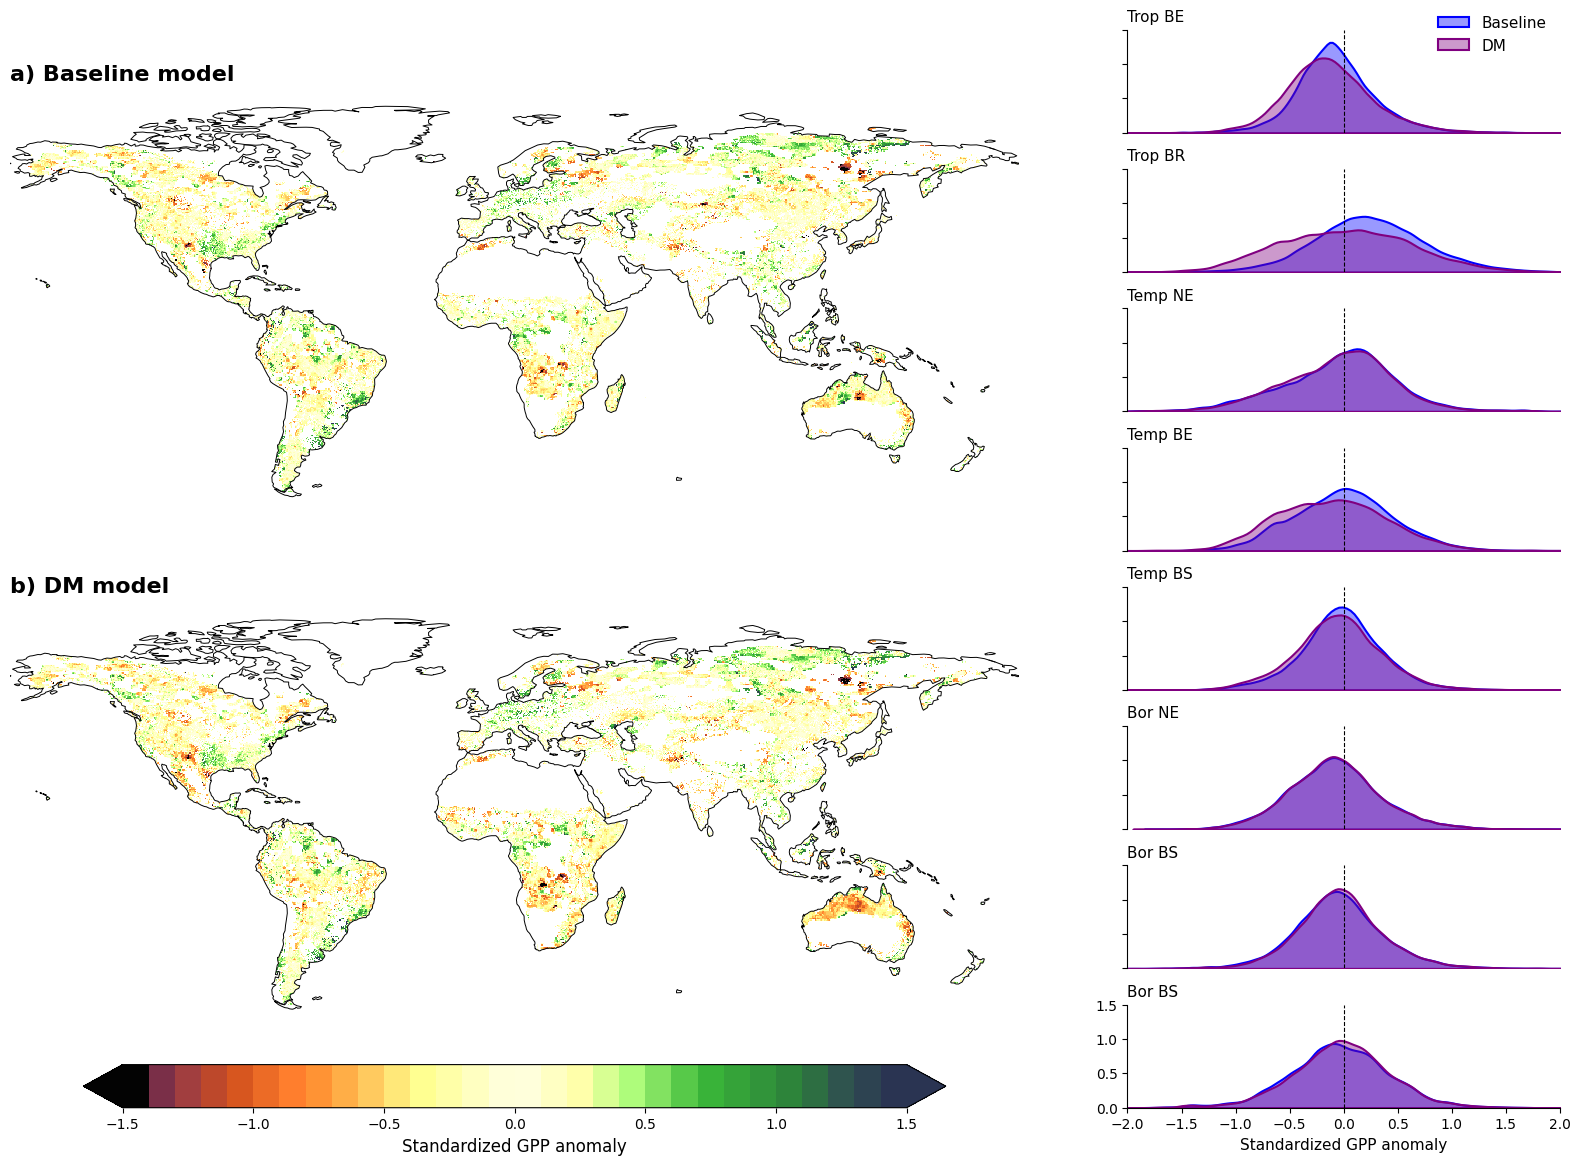

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import seaborn as sns
import numpy as np

# --------------------------------------------------
# Align mask
# --------------------------------------------------
lsm = lsm.interp_like(GPP_tree_MYD_base)

# --------------------------------------------------
# Apply masks
# --------------------------------------------------
base_land = (
    GPP_tree_MYD_base
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_base.lat > -60)
)

DM_land = (
    GPP_tree_MYD_DM
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_DM.lat > -60)
)



# --------------------------------------------------
# PFT names
# --------------------------------------------------
pft_names = [
    "Trop BE",
    "Trop BR",
    "Temp NE",
    "Temp BE",
    "Temp BS",
    "Bor NE",
    "Bor BS",
    "Bor BS"
]

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    nrows=8,
    ncols=2,
    width_ratios=[2.8, 1.2],
    hspace=0.35,
    wspace=0.15
)

# --------------------------------------------------
# Projection
# --------------------------------------------------
proj = ccrs.PlateCarree(central_longitude=11)

# ==================================================
# LEFT COLUMN: MAPS
# ==================================================

# -----------------------------------
# BASE MAP
# -----------------------------------
ax_map1 = fig.add_subplot(gs[0:4, 0], projection=proj)

vmin = -1.5
vmax = 1.5

im = base_land.plot(
    ax=ax_map1,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map1.coastlines(linewidth=0.7)

ax_map1.set_title("")


ax_map1.set_title(
    "a) Baseline model",
    fontsize=16,
    loc="left",     
    fontweight='bold'
)



ax_map1.spines['geo'].set_visible(False)

# -----------------------------------
# DM MAP
# -----------------------------------
ax_map2 = fig.add_subplot(gs[4:8, 0], projection=proj)

DM_land.plot(
    ax=ax_map2,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map2.coastlines(linewidth=0.7)

ax_map2.set_title("")

ax_map2.set_title(
    "b) DM model",
    fontsize=16,
    loc="left",
    fontweight='bold'
)



ax_map2.spines['geo'].set_visible(False)

ax_map1.set_global()
ax_map2.set_global()

ax_map1.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax_map2.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

# ==================================================
# COLORBAR
# ==================================================
cbar = fig.colorbar(
    im,
    ax=[ax_map1, ax_map2],
    orientation="horizontal",
    fraction=0.04,
    pad=0.04,
    extend="both"
)

cbar.set_label(
    "Standardized GPP anomaly",
    fontsize=12
)

# ==================================================
# RIGHT COLUMN: KDEs
# ==================================================
kde_axes = []

shared_ax = None

for i in range(8):

    # ----------------------------------------------
    # Shared x-axis
    # ----------------------------------------------
    if i == 0:
        ax = fig.add_subplot(gs[i, 1])
        shared_ax = ax
    else:
        ax = fig.add_subplot(gs[i, 1], sharex=shared_ax)

    # ----------------------------------------------
    # Extract values
    # ----------------------------------------------
    base_vals = (
        GPP_MYD_PFT_base.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_base.lat > -60)
        .values
        .flatten()
    )

    dm_vals = (
        GPP_MYD_PFT_DM.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_DM.lat > -60)
        .values
        .flatten()
    )

    # ----------------------------------------------
    # Remove NaNs
    # ----------------------------------------------
    base_vals = base_vals[np.isfinite(base_vals)]
    dm_vals   = dm_vals[np.isfinite(dm_vals)]

    # ----------------------------------------------
    # Optional subsampling
    # ----------------------------------------------
    max_points = 200000

    if len(base_vals) > max_points:
        base_vals = np.random.choice(
            base_vals,
            max_points,
            replace=False
        )

    if len(dm_vals) > max_points:
        dm_vals = np.random.choice(
            dm_vals,
            max_points,
            replace=False
        )

    # ----------------------------------------------
    # KDE plots
    # ----------------------------------------------
    sns.kdeplot(
        base_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="Baseline", color = 'blue'
    )

    sns.kdeplot(
        dm_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="DM", color = 'purple'
    )

    # ----------------------------------------------
    # Formatting
    # ----------------------------------------------
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 1.5)

    ax.set_title(
        pft_names[i],
        fontsize=11,
        loc="left"
    )

    ax.set_ylabel("")


    # ----------------------------------------------
    # Cleaner shared-axis styling
    # ----------------------------------------------
    if i < 7:
        # remove x-axis labels/ticks for upper panels
        ax.set_xlabel("")
        ax.tick_params(
            axis='x',
            which='both',
            bottom=False,
            labelbottom=False
        )
        
        ax.tick_params(
        axis='y',
        labelleft=False
        )

        # optional: hide bottom spine too
        ax.spines['bottom'].set_visible(False)

    else:
        # keep only on bottom panel
        ax.set_xlabel("Standardized GPP anomaly", fontsize=11)

        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True
        )

    # cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    kde_axes.append(ax)

# ==================================================
# LEGEND
# ==================================================
handles, labels = kde_axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9, 0.9),
    frameon=False,
    fontsize=11
)

# ==================================================
# FINAL LAYOUT
# ==================================================
# plt.tight_layout()

plt.savefig("/home/druijsch/scripts/2026_06_03_drought_response_DM_vs_base_vs_obs/GPP_anom_maps_kdes_v4.png", dpi=300)

plt.show()

In [30]:
import matplotlib.colors as mcolors

def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - amount * (1 - x) for x in c)

light_purple = lighten_color("purple", amount=0.75)
light_purple

(0.6264705882352941, 0.25, 0.6264705882352941)

In [31]:
import matplotlib.colors as mcolors

def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - amount * (1 - x) for x in c)

light_blue= lighten_color("blue", amount=0.75)
light_blue

(0.25, 0.25, 1.0)

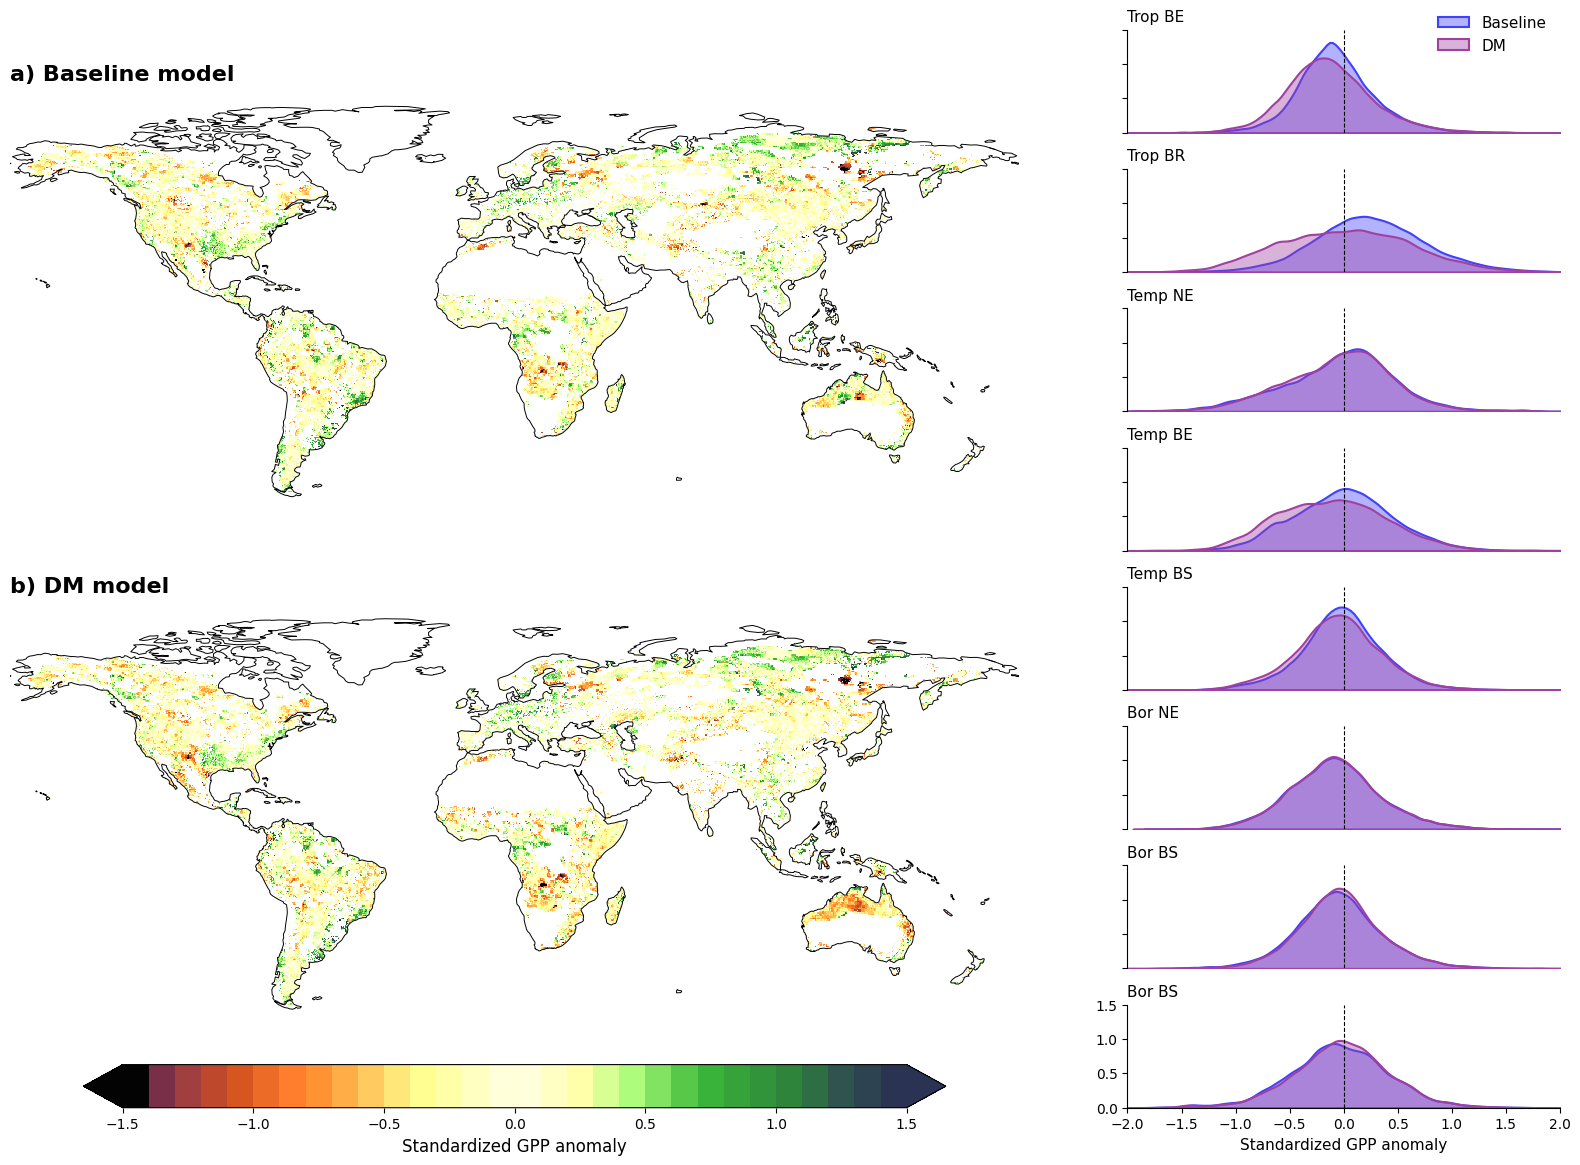

In [32]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import seaborn as sns
import numpy as np

# --------------------------------------------------
# Align mask
# --------------------------------------------------
lsm = lsm.interp_like(GPP_tree_MYD_base)

# --------------------------------------------------
# Apply masks
# --------------------------------------------------
base_land = (
    GPP_tree_MYD_base
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_base.lat > -60)
)

DM_land = (
    GPP_tree_MYD_DM
    .where(lsm > 0.5)
    .where(base_PFT_FPC[0:8].sum("pft") > 0.01)
    .where(GPP_tree_MYD_DM.lat > -60)
)



# --------------------------------------------------
# PFT names
# --------------------------------------------------
pft_names = [
    "Trop BE",
    "Trop BR",
    "Temp NE",
    "Temp BE",
    "Temp BS",
    "Bor NE",
    "Bor BS",
    "Bor BS"
]

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    nrows=8,
    ncols=2,
    width_ratios=[2.8, 1.2],
    hspace=0.35,
    wspace=0.15
)

# --------------------------------------------------
# Projection
# --------------------------------------------------
proj = ccrs.PlateCarree(central_longitude=11)

# ==================================================
# LEFT COLUMN: MAPS
# ==================================================

# -----------------------------------
# BASE MAP
# -----------------------------------
ax_map1 = fig.add_subplot(gs[0:4, 0], projection=proj)

vmin = -1.5
vmax = 1.5

im = base_land.plot(
    ax=ax_map1,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map1.coastlines(linewidth=0.7)

ax_map1.set_title("")


ax_map1.set_title(
    "a) Baseline model",
    fontsize=16,
    loc="left",     
    fontweight='bold'
)



ax_map1.spines['geo'].set_visible(False)

# -----------------------------------
# DM MAP
# -----------------------------------
ax_map2 = fig.add_subplot(gs[4:8, 0], projection=proj)

DM_land.plot(
    ax=ax_map2,
    transform=ccrs.PlateCarree(),
    cmap=discrete_cmap,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map2.coastlines(linewidth=0.7)

ax_map2.set_title("")

ax_map2.set_title(
    "b) DM model",
    fontsize=16,
    loc="left",
    fontweight='bold'
)



ax_map2.spines['geo'].set_visible(False)

ax_map1.set_global()
ax_map2.set_global()

ax_map1.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax_map2.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

# ==================================================
# COLORBAR
# ==================================================
cbar = fig.colorbar(
    im,
    ax=[ax_map1, ax_map2],
    orientation="horizontal",
    fraction=0.04,
    pad=0.04,
    extend="both"
)

cbar.set_label(
    "Standardized GPP anomaly",
    fontsize=12
)

# ==================================================
# RIGHT COLUMN: KDEs
# ==================================================
kde_axes = []

shared_ax = None

for i in range(8):

    # ----------------------------------------------
    # Shared x-axis
    # ----------------------------------------------
    if i == 0:
        ax = fig.add_subplot(gs[i, 1])
        shared_ax = ax
    else:
        ax = fig.add_subplot(gs[i, 1], sharex=shared_ax)

    # ----------------------------------------------
    # Extract values
    # ----------------------------------------------
    base_vals = (
        GPP_MYD_PFT_base.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_base.lat > -60)
        .values
        .flatten()
    )

    dm_vals = (
        GPP_MYD_PFT_DM.isel(pft=i)
        .where(lsm > 0.5)
        .where(base_PFT_FPC.isel(pft=i) > 0.01)
        .where(GPP_MYD_PFT_DM.lat > -60)
        .values
        .flatten()
    )

    # ----------------------------------------------
    # Remove NaNs
    # ----------------------------------------------
    base_vals = base_vals[np.isfinite(base_vals)]
    dm_vals   = dm_vals[np.isfinite(dm_vals)]

    # ----------------------------------------------
    # Optional subsampling
    # ----------------------------------------------
    max_points = 200000

    if len(base_vals) > max_points:
        base_vals = np.random.choice(
            base_vals,
            max_points,
            replace=False
        )

    if len(dm_vals) > max_points:
        dm_vals = np.random.choice(
            dm_vals,
            max_points,
            replace=False
        )

    # ----------------------------------------------
    # KDE plots
    # ----------------------------------------------
    sns.kdeplot(
        base_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="Baseline", color = light_blue
    )

    sns.kdeplot(
        dm_vals,
        ax=ax,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        label="DM", color = light_purple
    )

    # ----------------------------------------------
    # Formatting
    # ----------------------------------------------
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 1.5)

    ax.set_title(
        pft_names[i],
        fontsize=11,
        loc="left"
    )

    ax.set_ylabel("")


    # ----------------------------------------------
    # Cleaner shared-axis styling
    # ----------------------------------------------
    if i < 7:
        # remove x-axis labels/ticks for upper panels
        ax.set_xlabel("")
        ax.tick_params(
            axis='x',
            which='both',
            bottom=False,
            labelbottom=False
        )
        
        ax.tick_params(
        axis='y',
        labelleft=False
        )

        # optional: hide bottom spine too
        ax.spines['bottom'].set_visible(False)

    else:
        # keep only on bottom panel
        ax.set_xlabel("Standardized GPP anomaly", fontsize=11)

        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True
        )

    # cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    kde_axes.append(ax)

# ==================================================
# LEGEND
# ==================================================
handles, labels = kde_axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9, 0.9),
    frameon=False,
    fontsize=11
)

# ==================================================
# FINAL LAYOUT
# ==================================================
# plt.tight_layout()

plt.savefig("/home/druijsch/scripts/2026_06_03_drought_response_DM_vs_base_vs_obs/GPP_anom_maps_kdes_v4.png", dpi=300)

plt.show()